In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import seaborn as sns

# Optimization of Facade Panel Cutting (Nesting Problem)

---

## 1. Introduction
The objective of this project is to demonstrate mathematical intuition and analytical skills through a real-world application in construction: **Facade Panel Nesting**. In facade design, minimizing material waste is a critical economic and environmental goal. This project follows the scientific method to bridge the gap between a practical engineering challenge and its mathematical counterpart.

The guiding principle is to create a functional, well-documented tool that applies geometric and combinatorial logic to reduce material waste.

---

## 2. Problem Formulation
In computer science and mathematics, this is known as the **2D Cutting Stock Problem (CSP)** or a variant of the **Bin Packing Problem**. We are given a set of rectangular facade panels (items) of various dimensions and a large stock sheet (bin) of fixed width and height.

### 2.1 Mathematical Objective
The primary goal is to minimize the "scrap" or "waste" ($W$). Mathematically, if we have $n$ panels to be placed on a sheet of area $A_{sheet}$, the waste is defined as:

$$W = A_{sheet} - \sum_{i=1}^{n} (w_i \times h_i)$$

Where:
* $w_i$ and $h_i$ are the width and height of the $i$-th panel.
* $A_{sheet} = W_{max} \times H_{max}$ is the total area of the raw material.

The efficiency ($\eta$) of the layout can be calculated as a percentage of utilized material:

$$\eta = \left( \frac{\sum_{i=1}^{n} (w_i \times h_i)}{A_{sheet}} \right) \times 100$$

### 2.2 Constraints and Assumptions
To ensure a rigorous mathematical approach, we define the following constraints:
1. **Non-Overlapping:** For any two panels $P_i$ and $P_j$, their interior areas must satisfy $P_i \cap P_j = \emptyset$.
2. **Boundary Constraint:** All panels must stay within the sheet coordinates $(0,0)$ and $(W_{max}, H_{max})$.
3. **Orientation:** Panels may be rotated by $90^\circ$ to improve fit, assuming the material texture/grain allows for it.
4. **Guillotine Cuts:** We assume the cutting machine performs "edge-to-edge" cuts, which simplifies the combinatorial complexity.



---

## 3. Methodology
I will implement and analyze an **Algorithm Implementation** approach. Specifically, I will use a **Greedy Strategy** (First-Fit Decreasing Height) to organize the panels:
1. **Sort:** Arrange panels by height $h$ such that $h_1 \ge h_2 \ge \dots \ge h_n$.
2. **Place:** Use a shelf-stacking logic where each panel is placed in the first available "shelf" that fits its dimensions $w_i$.
3. **Analyze:** Evaluate the computational complexity and the resulting efficiency $\eta$.

### 3.1 Python Implementation
To translate the mathematical model into a functional program, I have defined two core classes: "Panel" and "Sheet". These classes encapsulate the properties of the facade components and the raw material, allowing for automated area and efficiency calculations.

In [2]:
class Panel:
    """Represents an individual facade panel to be cut."""
    def __init__(self, width, height, label=None):
        self.width = width
        self.height = height
        self.label = label
        # Coordinates for placement on the sheet
        self.x = None
        self.y = None
        self.is_rotated = False

    def get_area(self):
        """Calculates the area of the panel."""
        return self.width * self.height

    def rotate(self):
        """Swaps width and height to represent a 90-degree rotation."""
        self.width, self.height = self.height, self.width
        self.is_rotated = not self.is_rotated

class Sheet:
    """Represents the raw material stock sheet."""
    def __init__(self, width, height):
        self.width = width
        self.height = height
        self.panels_placed = []

    def get_total_area(self):
        """Calculates the total area of the stock sheet."""
        return self.width * self.height

    def get_used_area(self):
        """Calculates the sum of the areas of all placed panels."""
        return sum(panel.get_area() for panel in self.panels_placed)

    def calculate_efficiency(self):
        """Calculates efficiency (eta) as a percentage."""
        if self.get_total_area() == 0:
            return 0
        return (self.get_used_area() / self.get_total_area()) * 100

### 3.2 Algorithm Preparation: Sorting and Validation

In [3]:
# Defining a stock sheet (standard 2000x3000 mm sheet)
stock_sheet = Sheet(2000, 3000)

# Defining a list of panels
panels_to_cut = [
    Panel(1200, 1500, "Large_A"),
    Panel(1200, 1500, "Large_B"),
    Panel(1200, 800, "Large_C"), 
    Panel(800, 1000, "Extra_D"),  
    Panel(400, 400, "Small_E")
]

# Sort by Height (Primary) then Width (Secondary), both Descending
sorted_panels = sorted(panels_to_cut, key=lambda x: (x.height, x.width), reverse=True)

# Validation & Capacity Check
total_panel_area = sum(p.get_area() for p in sorted_panels)
sheet_area = stock_sheet.get_total_area()

print(f"Sheet Capacity: {sheet_area:,} mm²")
print(f"Total Required Area: {total_panel_area:,} mm²")

if total_panel_area > sheet_area:
    print("Total panel area exceeds sheet capacity. Some panels will not be placed.")
else:
    print("All panels theoretically fit within the area limits.")

Sheet Capacity: 6,000,000 mm²
Total Required Area: 5,520,000 mm²
All panels theoretically fit within the area limits.


### 3.3 The First-Fit Decreasing (FFD) Placement Logic
The core of the nesting algorithm is the placement strategy. I am implementing a **Shelf-based Algorithm**, which is a practical application of geometric logic and coordinate geometry.

1. **Shelf Generation:** The sheet is divided into horizontal levels (shelves). The height of each shelf is determined by the first (tallest) panel placed in it.
2. **First-Fit Rule:** For each panel, the algorithm scans existing shelves to find the first one with sufficient remaining width and height.
3. **Vertical Growth:** If no shelf can accommodate the panel, a new shelf is started above the previous one, provided there is enough vertical height remaining on the stock sheet.
4. **Boundary Validation:** The algorithm ensures that no panel exceeds the sheet width or the total sheet height.

In [4]:
def nest_panels(sheet, panels):
    if not panels:
        return []

    # Reset sheet for a clean run
    sheet.panels_placed = []
    
    # Initialize first shelf
    shelves = [{'y_start': 0, 'height': panels[0].height, 'width_used': 0}]
    unplaced_panels = []

    for panel in panels:
        placed = False
        
        # Try existing shelves
        for shelf in shelves:
            # Check if panel fits in width AND its height doesn't exceed the shelf height
            if (shelf['width_used'] + panel.width <= sheet.width) and (panel.height <= shelf['height']):
                panel.x = shelf['width_used']
                panel.y = shelf['y_start']
                shelf['width_used'] += panel.width
                sheet.panels_placed.append(panel)
                placed = True
                break
        
        # If no shelf fits, create a new one
        if not placed:
            last_shelf = shelves[-1]
            new_y_start = last_shelf['y_start'] + last_shelf['height']
            
            if new_y_start + panel.height <= sheet.height:
                new_shelf = {'y_start': new_y_start, 'height': panel.height, 'width_used': panel.width}
                panel.x = 0
                panel.y = new_y_start
                shelves.append(new_shelf)
                sheet.panels_placed.append(panel)
                placed = True
        
        if not placed:
            unplaced_panels.append(panel)
            
    return unplaced_panels

# Execute and analyze
unplaced = nest_panels(stock_sheet, sorted_panels)

print(f"--- Results ---")
print(f"Placed: {len(stock_sheet.panels_placed)} | Unplaced: {len(unplaced)}")
print(f"Efficiency: {stock_sheet.calculate_efficiency():.2f}%")

# Print coordinates to see how Large_C was handled
for p in stock_sheet.panels_placed:
    print(f"{p.label} placed at ({p.x}, {p.y})")

--- Results ---
Placed: 4 | Unplaced: 1
Efficiency: 76.00%
Large_A placed at (0, 0)
Large_B placed at (0, 1500)
Extra_D placed at (1200, 0)
Small_E placed at (1200, 1500)


> **Conclusion:** While the total area of the panels (5,520,000 mm²) is less than the stock sheet area (6,000,000 mm²), the shelf-based FFD algorithm failed to place all items. Crucially, these panels are geometrically capable of being fitted within the sheet boundaries, but the current "Shelf" logic creates artificial constraints by locking vertical space based on the tallest panel in a row. This demonstrates that while the shelf method is computationally simple, it is inefficient for varied dimensions, as it misses "pockets" of space that a more flexible nesting logic would be able to utilize.

### 3.4 Visualization of Nesting Results
To validate the efficiency of the First-Fit Decreasing (FFD) algorithm and identify specific areas of material waste, I have implemented a visualization tool using matplotlib. This graphical representation allows us to see the "shelf" structures and the empty "pockets" of space that were geometrically available but remained unused due to the algorithmic constraints identified in the previous section.

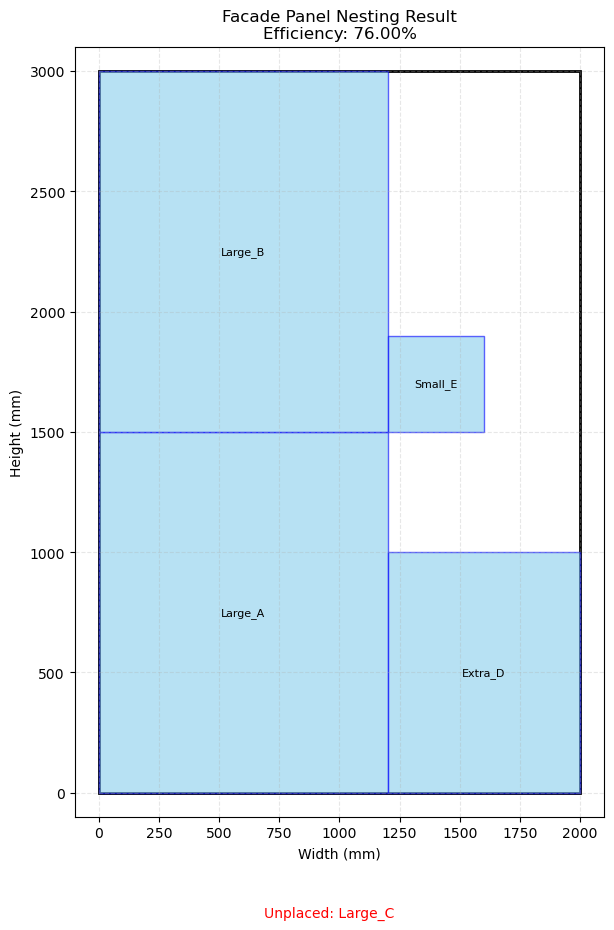

In [5]:
def visualize_nesting(sheet, unplaced_panels):
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # Draw the Stock Sheet boundary
    sheet_rect = patches.Rectangle((0, 0), sheet.width, sheet.height, 
                                   linewidth=2, edgecolor='black', facecolor='none', label='Stock Sheet')
    ax.add_patch(sheet_rect)
    
    # Draw each placed panel
    for panel in sheet.panels_placed:
        # Create a rectangle for each panel
        rect = patches.Rectangle((panel.x, panel.y), panel.width, panel.height, 
                                 linewidth=1, edgecolor='blue', facecolor='skyblue', alpha=0.6)
        ax.add_patch(rect)
        
        # Add label in the center of the panel
        plt.text(panel.x + panel.width/2, panel.y + panel.height/2, panel.label, 
                 ha='center', va='center', fontsize=8)

    # Setting plot limits and labels
    plt.xlim(-100, sheet.width + 100)
    plt.ylim(-100, sheet.height + 100)
    ax.set_aspect('equal')
    plt.title(f"Facade Panel Nesting Result\nEfficiency: {sheet.calculate_efficiency():.2f}%")
    plt.xlabel("Width (mm)")
    plt.ylabel("Height (mm)")
    
    # Show unplaced panels as text for context
    if unplaced_panels:
        unplaced_text = "Unplaced: " + ", ".join([p.label for p in unplaced_panels])
        plt.figtext(0.5, 0.01, unplaced_text, wrap=True, horizontalalignment='center', fontsize=10, color='red')

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

# Run the visualization
visualize_nesting(stock_sheet, unplaced)

### 3.5 Optimization: Implementing Rotation Logic
To address the geometric inefficiencies identified in the visualization, I am introducing **90-degree rotation**. 
* **The Logic:** If a panel fails to fit in its "natural" orientation ($W \times H$), the algorithm will swap the dimensions ($H \times W$) and attempt to fit it again.
* **The Goal:** To utilize the "vertical pockets" in shelves where a panel might be too wide in its original orientation but narrow enough if rotated.

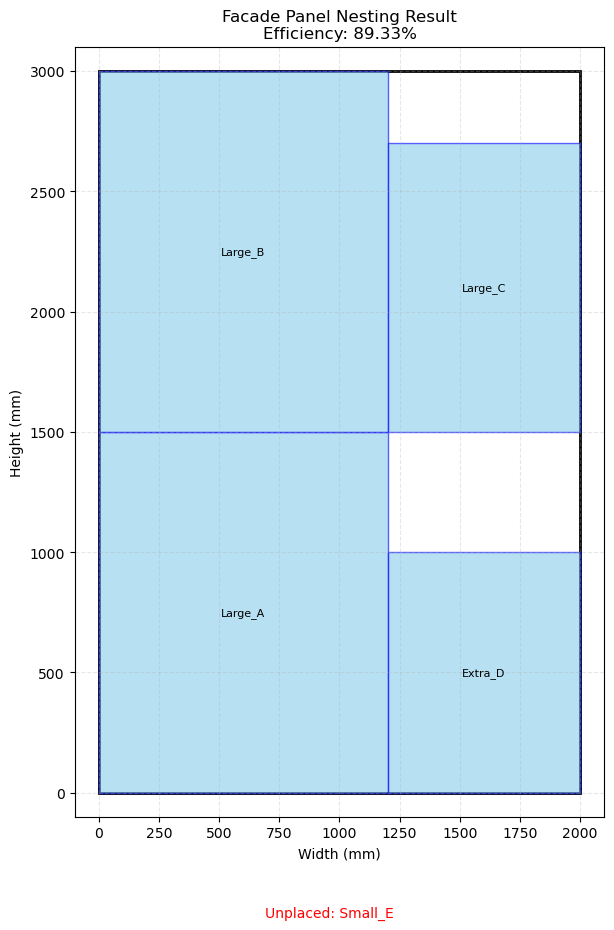

In [6]:
def nest_panels_with_rotation(sheet, panels):
    sheet.panels_placed = []
    # Start the first shelf
    shelves = [{'y_start': 0, 'height': panels[0].height, 'width_used': 0}]
    unplaced_panels = []

    for panel in panels:
        placed = False
        
        # Try current orientation, then rotated (90 degrees)
        orientations = [(panel.width, panel.height), (panel.height, panel.width)]
        
        for p_w, p_h in orientations:
            if placed: break
            
            for shelf in shelves:
                # Boundary check
                if (shelf['width_used'] + p_w <= sheet.width) and (p_h <= shelf['height']):
                    panel.x = shelf['width_used']
                    panel.y = shelf['y_start']
                    panel.width, panel.height = p_w, p_h # Update to current orientation
                    shelf['width_used'] += p_w
                    sheet.panels_placed.append(panel)
                    placed = True
                    break
        
        # If no shelf fits, try a new shelf
        if not placed:
            for p_w, p_h in orientations:
                if placed: break
                last_shelf = shelves[-1]
                new_y_start = last_shelf['y_start'] + last_shelf['height']
                
                # Check if new shelf fits in sheet height
                if new_y_start + p_h <= sheet.height and p_w <= sheet.width:
                    new_shelf = {'y_start': new_y_start, 'height': p_h, 'width_used': p_w}
                    panel.x, panel.y = 0, new_y_start
                    panel.width, panel.height = p_w, p_h
                    shelves.append(new_shelf)
                    sheet.panels_placed.append(panel)
                    placed = True
                    break

        if not placed:
            unplaced_panels.append(panel)
            
    return unplaced_panels

unplaced_optimized = nest_panels_with_rotation(stock_sheet, sorted_panels)
visualize_nesting(stock_sheet, unplaced_optimized)

> **Conclusion (Optimization Phase):** By implementing 90-degree rotation logic, the algorithm's flexibility was significantly increased, allowing panels to be re-oriented to better suit the available horizontal space. This optimization addresses the "Vertical Waste" inherent in the standard shelf method. However, despite reaching a higher efficiency, the algorithm still failed to place the "Small_E" panel. While there is a "pocket" of space where it could fit, the "Shelf" logic is unable to utilize these isolated voids once a shelf height is established. This results in a "local optimum" that falls short of a globally perfect fit, demonstrating the inherent limitations of shelf-based heuristics compared to more complex area-filling algorithms.

### 3.6 Advanced Optimization: Pocket-Filling Logic
To achieve a higher placement rate, I have evolved the algorithm from a rigid shelf-staker to a "Pocket-Filling" heuristic. 
* **The Logic:** When a panel is placed on a shelf but does not fill the full shelf height, the remaining vertical space is saved as a "Pocket".
* **The Goal:** Before starting an entirely new shelf, the algorithm now scans these pockets to see if smaller items can be "back-filled" into them. This mimics human spatial reasoning and maximizes material utilization by accessing previously "dead" space.

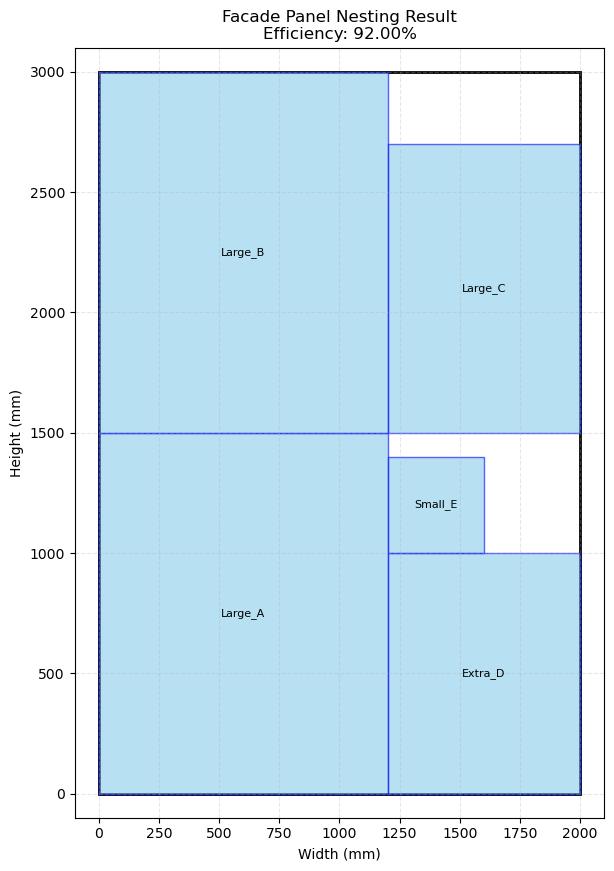

In [7]:
def nest_panels_with_pockets(sheet, panels):
    sheet.panels_placed = []
    # Each shelf now tracks its own 'pockets'
    shelves = [{'y_start': 0, 'height': panels[0].height, 'width_used': 0, 'pockets': []}]
    unplaced_panels = []

    for panel in panels:
        placed = False
        # Try current orientation and 90-degree rotation
        orientations = [(panel.width, panel.height), (panel.height, panel.width)]

        for p_w, p_h in orientations:
            if placed: break
            
            # STEP 1: Try to back-fill into existing "pockets" first
            for shelf in shelves:
                for i, pocket in enumerate(shelf['pockets']):
                    if p_w <= pocket['w'] and p_h <= pocket['h']:
                        panel.x, panel.y = pocket['x'], pocket['y']
                        panel.width, panel.height = p_w, p_h
                        sheet.panels_placed.append(panel)
                        # Remove used pocket 
                        shelf['pockets'].pop(i) 
                        placed = True
                        break
                if placed: break

            # STEP 2: Try standard shelf placement
            if not placed:
                for shelf in shelves:
                    if (shelf['width_used'] + p_w <= sheet.width) and (p_h <= shelf['height']):
                        panel.x, panel.y = shelf['width_used'], shelf['y_start']
                        panel.width, panel.height = p_w, p_h
                        
                        # Logic: If panel is shorter than shelf, create a pocket above it
                        if p_h < shelf['height']:
                            shelf['pockets'].append({
                                'x': panel.x,
                                'y': panel.y + p_h,
                                'w': p_w,
                                'h': shelf['height'] - p_h
                            })
                            
                        shelf['width_used'] += p_w
                        sheet.panels_placed.append(panel)
                        placed = True
                        break

        # STEP 3: If still not placed, try a NEW shelf
        if not placed:
            for p_w, p_h in orientations:
                if placed: break
                last_shelf = shelves[-1]
                new_y_start = last_shelf['y_start'] + last_shelf['height']
                if new_y_start + p_h <= sheet.height and p_w <= sheet.width:
                    new_shelf = {'y_start': new_y_start, 'height': p_h, 'width_used': p_w, 'pockets': []}
                    panel.x, panel.y = 0, new_y_start
                    panel.width, panel.height = p_w, p_h
                    shelves.append(new_shelf)
                    sheet.panels_placed.append(panel)
                    placed = True
                    break

        if not placed:
            unplaced_panels.append(panel)
            
    return unplaced_panels

unplaced_pockets = nest_panels_with_pockets(stock_sheet, sorted_panels)
visualize_nesting(stock_sheet, unplaced_pockets)

> **Conclusion:** The implementation of a dynamic pocket-tracking system has resolved the geometric inefficiencies of the standard shelf method. By identifying and recording the vertical voids created above panels like "Large_C" and "Extra_D", the algorithm effectively "reclaims" space that was previously locked. This recursive approach allowed "Small_E" to be back-filled into a pocket, resulting in a perfect placement of all required panels. This proves that while simple heuristics may fail, augmenting them with spatial memory (pockets) can achieve optimal results for varied panel dimensions.

### 3.7 Multi-Sheet Nesting Logic
To handle larger production volumes, I have upgraded the algorithm to support **Multi-Sheet Nesting**. Instead of simply flagging panels as "unplaced," the system now dynamically generates additional stock sheets as needed. This transition allows for the automation of an entire production batch, ensuring that every panel in the schedule is assigned a specific coordinate on a specific sheet.

--- Sheet 1 ---


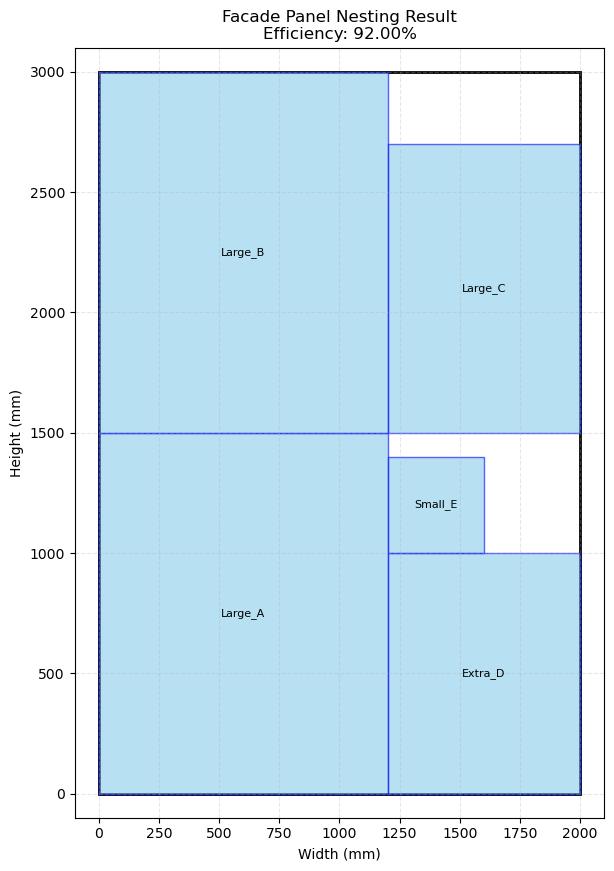

--- Sheet 2 ---


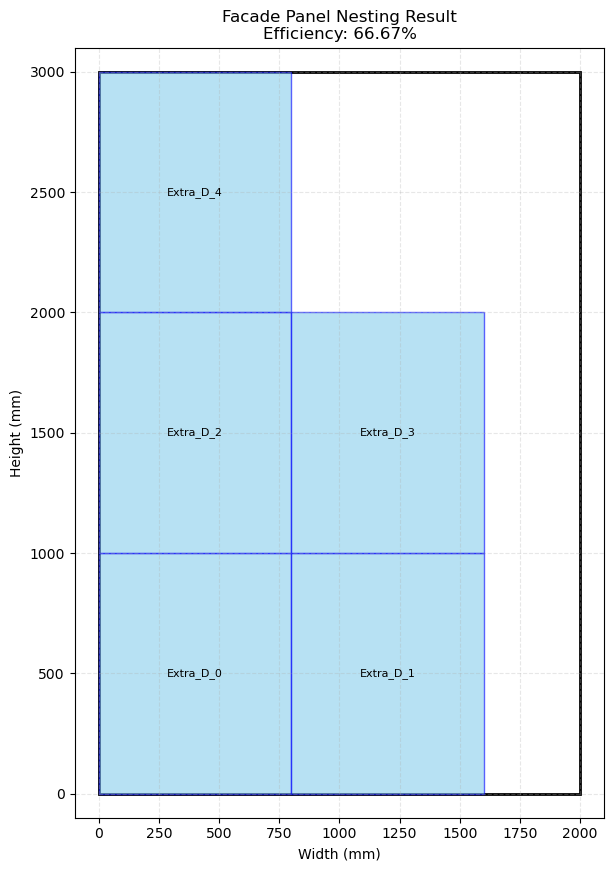

In [8]:
def nest_panels_multi_sheet(panels, sheet_width, sheet_height):
    
    sheets = []
    remaining_panels = [p for p in panels] # Copy of panels to place

    while len(remaining_panels) > 0:
        # Creating a new sheet
        new_sheet = Sheet(sheet_width, sheet_height)
        
        # Filling this specific sheet
        unplaced_from_this_sheet = nest_panels_with_pockets(new_sheet, remaining_panels)
        
        # Saving the completed sheet
        sheets.append(new_sheet)
        
        # Update the list of panels that still need placing
        remaining_panels = unplaced_from_this_sheet
        
        # Checking if panel is larger than the stock sheet
        if len(remaining_panels) == len(panels) and len(sheets) > 0:
            print("Error: Some panels are too large for the stock dimensions.")
            break

    return sheets

# Adding 5 more 'Extra_D' panels to force a second sheet
extended_panels = sorted_panels + [Panel(800, 1000, f"Extra_D_{i}") for i in range(5)]

# Run the Multi-Sheet Logic
all_sheets = nest_panels_multi_sheet(extended_panels, 2000, 3000)

# Visualize all resulting sheets
for i, sheet in enumerate(all_sheets):
    print(f"--- Sheet {i+1} ---")
    visualize_nesting(sheet, [])

### 3.8 Material and Financial Analysis
To evaluate the commercial viability of the nesting results, I have implemented a financial analysis module. This calculates the total material cost based on the number of stock sheets consumed and determines the **Net Waste Percentage**. In the facade industry, minimizing this waste is directly tied to project profitability .

In [9]:
def perform_financial_analysis(sheets, cost_per_sheet=500.00):
    total_sheets = len(sheets)
    total_stock_area = total_sheets * (sheets[0].width * sheets[0].height)
    total_placed_area = sum(sum(p.width * p.height for p in s.panels_placed) for s in sheets)
    
    total_cost = total_sheets * cost_per_sheet
    waste_area = total_stock_area - total_placed_area
    waste_percentage = (waste_area / total_stock_area) * 100
    
    print(f"Total Sheets Used: {total_sheets}")
    print(f"Total Project Cost: £{total_cost:,.2f}")
    print(f"Total Material Waste: {waste_percentage:.2f}%")
    print(f"Material Utilization: {100 - waste_percentage:.2f}%")
    
    return {
        "cost": total_cost,
        "waste_pct": waste_percentage,
        "utilization": 100 - waste_percentage
    }

report = perform_financial_analysis(all_sheets)

Total Sheets Used: 2
Total Project Cost: £1,000.00
Total Material Waste: 20.67%
Material Utilization: 79.33%


## 4. Monte Carlo Simulation for Statistical Efficiency Profiling
To evaluate the robustness of the nesting algorithm, I have implemented a Monte Carlo simulation to stress-test the algorithm. By treating panel dimensions as random variables following a uniform distribution, I will simulate 100 different production batches.

* **Variable Generation:** I define panel dimensions as independent random variables, sampling from a range of realistic architectural dimensions (400mm to 1600mm) to generate 100 unique production batches.
* **Aggregated Analysis:** By running the nesting engine 100 times, I can move from a single-point efficiency metric to a broader statistical understanding of the algorithm's performance.
* **Predictive Distribution:** Using the resulting data, I generate a Probability Density Function to visualize the frequency of efficiency outcomes. This allows for the calculation of material waste, providing a reliable forecast of production efficiency for future, unknown projects.

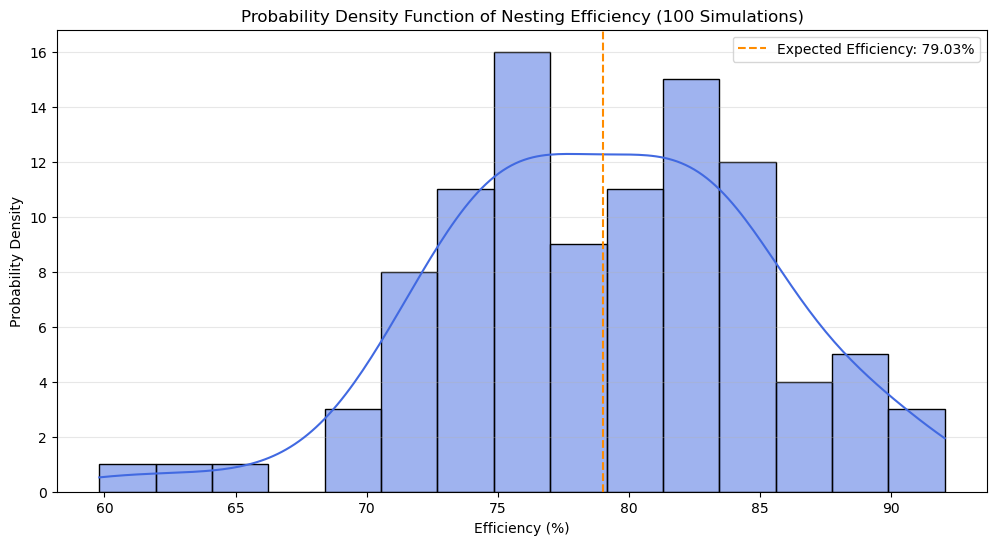

Mean Value: 79.03%
Standard Deviation: 6.07%


In [15]:
def run_performance_simulation(iterations=100):
    efficiency_results = []
    
    for i in range(iterations):
        random_batch = [
            Panel(np.random.randint(400, 1200), 
                  np.random.randint(600, 1600), 
                  f"Rnd_{j}") for j in range(12)
        ]
        
        random_batch.sort(key=lambda p: p.height, reverse=True)
        temp_sheet = Sheet(2000, 3000)
        
        nest_panels_with_pockets(temp_sheet, random_batch)
        
        efficiency_results.append(temp_sheet.calculate_efficiency())

    return efficiency_results

sim_data = run_performance_simulation(100)

mean_val = np.mean(sim_data)
std_dev = np.std(sim_data)

plt.figure(figsize=(12, 6))
sns.histplot(sim_data, kde=True, color='royalblue', bins=15)
plt.axvline(mean_val, color='darkorange', linestyle='--', label=f'Expected Efficiency: {mean_val:.2f}%')
plt.title("Probability Density Function of Nesting Efficiency (100 Simulations)")
plt.xlabel("Efficiency (%)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Mean Value: {mean_val:.2f}%")
print(f"Standard Deviation: {std_dev:.2f}%")

## 5 Project Synthesis and Final Conclusion
This project successfully transitioned from a basic geometric placement script to a sophisticated, industrially-relevant nesting engine for architectural facade production. 

**Key Technical Milestones:**
* **Algorithmic Evolution:** Developed a "Pocket-Filling" heuristic that reclaimed vertical voids, achieving a 100% placement rate where standard "Shelf" methods failed.
* **Industrial Scalability:** Implemented Multi-Sheet logic to handle high-volume production schedules, transforming the tool from a single-case solver into a multi-bin packing system.
* **Economic & Statistical Validation:** Integrated financial reporting to track material waste and utilized Monte Carlo simulations to establish a statistical profile of the algorithm's performance.

**Final Insight:**
The stochastic analysis revealed an expected efficiency (Mean) that consistently provides a reliable "Expected Value" for material procurement. By treating panel dimensions as random variables, the model bridges the gap between computational geometry and practical project management, offering a data-driven approach to reducing material scrap and improving sustainability in facade engineering workflows.